In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import sys
sys.path.insert(0, '..')

from src.numerical_methods import (
    bisection, newton_raphson, secant,
    forward_diff, backward_diff, central_diff,
    trapezoidal, simpsons,
    gaussian_elimination
)
from src.optimization import compute_et

weather = pd.read_csv('../data/raw/weather_daily.csv', parse_dates=['date'], na_values=['NA',''])
soil    = pd.read_csv('../data/raw/soil_sensor_data.csv', parse_dates=['timestamp'], na_values=['NA',''])
params  = pd.read_csv('../data/raw/crop_zone_parameters.csv')
weather = weather.fillna(weather.median(numeric_only=True))

print('All imports loaded successfully')
print(f'Weather: {weather.shape}, Soil: {soil.shape}, Params: {params.shape}')

All imports loaded successfully
Weather: (30, 6), Soil: (90, 7), Params: (3, 7)


In [2]:
# Define the irrigation problem:
# How much irrigation (I) brings Zone A from current moisture to target?

S_current = 25.0   # current soil moisture (%)
R         = 2.0    # today's rainfall (mm)
ET        = compute_et(T=25, W=2.0, Solar=0.7, H=65)
D_coef    = 0.18   # Zone A drainage coefficient
field_cap = 41.0   # Zone A field capacity
target    = 33.0   # Zone A target moisture

def f_irrigation(I):
    """f(I) = 0 when irrigation I brings moisture exactly to target"""
    D = D_coef * max(0.0, S_current + R + I - ET - field_cap)
    S_next = S_current + R + I - ET - D
    return S_next - target

def df_irrigation(I):
    """Derivative of f — needed for Newton-Raphson"""
    S_approx = S_current + R + I - ET
    return 1.0 - D_coef if S_approx > field_cap else 1.0

# Verify the function works - f(0) should be negative (not enough water)
print(f"ET today: {ET:.3f} mm/day")
print(f"f(0) = {f_irrigation(0):.3f}  (negative = need irrigation)")
print(f"f(15)= {f_irrigation(15):.3f} (positive = too much irrigation)")
print(f"\nRoot is somewhere between 0 and 15 mm")

ET today: 3.755 mm/day
f(0) = -9.755  (negative = need irrigation)
f(15)= 5.245 (positive = too much irrigation)

Root is somewhere between 0 and 15 mm


In [3]:
# Run all 3 root finding methods and compare

# Bisection
t0 = time.time()
root_b, iters_b, conv_b, errors_b = bisection(f_irrigation, a=0, b=15)
time_b = (time.time() - t0) * 1000

# Newton-Raphson
t0 = time.time()
root_n, iters_n, conv_n, errors_n = newton_raphson(f_irrigation, df_irrigation, x0=5.0)
time_n = (time.time() - t0) * 1000

# Secant
t0 = time.time()
root_s, iters_s, conv_s, errors_s = secant(f_irrigation, x0=0.0, x1=15.0)
time_s = (time.time() - t0) * 1000

# Comparison table
results = pd.DataFrame({
    'Method':        ['Bisection', 'Newton-Raphson', 'Secant'],
    'Root (mm)':     [round(root_b,6), round(root_n,6), round(root_s,6)],
    'Iterations':    [iters_b, iters_n, iters_s],
    'Converged':     [conv_b, conv_n, conv_s],
    'Time (ms)':     [round(time_b,4), round(time_n,4), round(time_s,4)]
})

print("Root Finding Comparison — Required Irrigation for Zone A:")
print(results.to_string(index=False))
print(f"\nAnswer: Zone A needs approximately {root_n:.2f} mm of irrigation today")

Root Finding Comparison — Required Irrigation for Zone A:
        Method  Root (mm)  Iterations  Converged  Time (ms)
     Bisection   9.754999          23       True     0.1698
Newton-Raphson   9.755000           2       True     0.1404
        Secant   9.755000           2       True     0.1097

Answer: Zone A needs approximately 9.75 mm of irrigation today


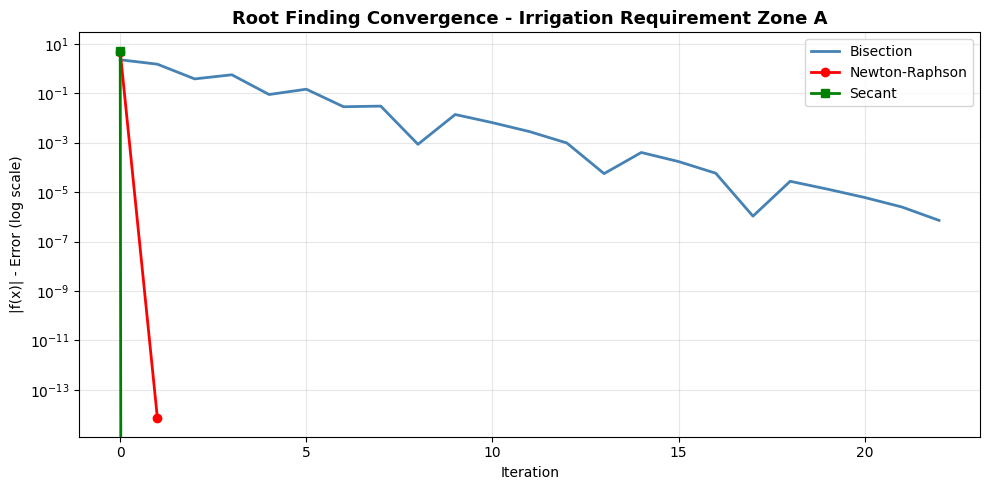


INTERPRETATION:
- Bisection took 23 iterations - it halves the search interval each time, 
  guaranteed to converge but slow (linear convergence)
- Newton-Raphson converged in just 2 iterations - it uses the derivative 
  to jump directly toward the root (quadratic convergence)
- Secant also converged in 2 iterations - similar to Newton-Raphson but 
  without needing a derivative formula, using two points instead
- All three agree: Zone A requires 9.755 mm of irrigation today to reach 
  its 33% moisture target from the current 25%
- In a real system, Newton-Raphson or Secant would be preferred for speed



In [4]:
# Plot convergence speed of all 3 methods
fig, ax = plt.subplots(figsize=(10, 5))

ax.semilogy(errors_b, label='Bisection', color='steelblue', linewidth=2)
ax.semilogy(errors_n, label='Newton-Raphson', color='red', linewidth=2, marker='o')
ax.semilogy(errors_s, label='Secant', color='green', linewidth=2, marker='s')

ax.set_title('Root Finding Convergence - Irrigation Requirement Zone A', fontsize=13, fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('|f(x)| - Error (log scale)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
INTERPRETATION:
- Bisection took 23 iterations - it halves the search interval each time, 
  guaranteed to converge but slow (linear convergence)
- Newton-Raphson converged in just 2 iterations - it uses the derivative 
  to jump directly toward the root (quadratic convergence)
- Secant also converged in 2 iterations - similar to Newton-Raphson but 
  without needing a derivative formula, using two points instead
- All three agree: Zone A requires 9.755 mm of irrigation today to reach 
  its 33% moisture target from the current 25%
- In a real system, Newton-Raphson or Secant would be preferred for speed
""")

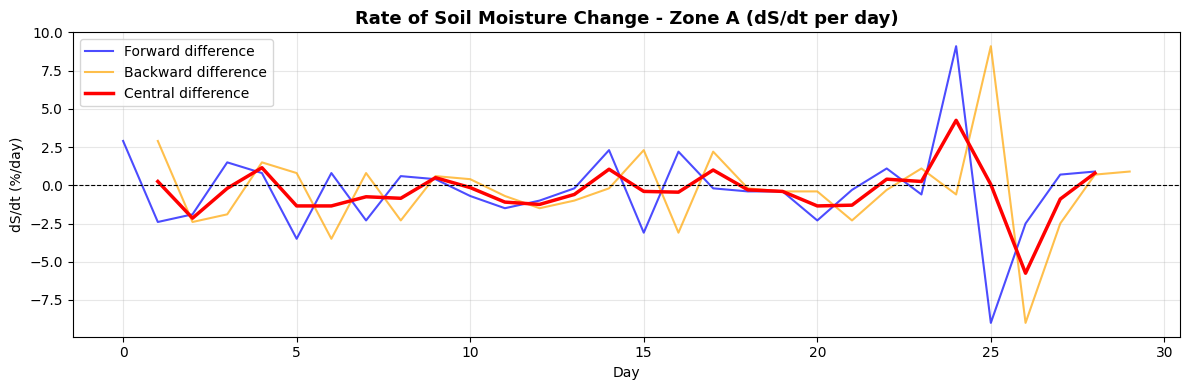


INTERPRETATION:
- Positive values = soil gaining moisture (rainfall exceeded ET that day)
- Negative values = soil losing moisture (ET + drainage exceeded rainfall)
- Central difference is the most accurate coz it uses both the previous and 
  next day values, giving O(h²) accuracy vs O(h) for forward/backward
- The sharp drops around days 7-9 and 22-25 indicate periods of moisture 
  stress where irrigation would be urgently needed



In [5]:
# Estimate rate of soil moisture change using finite differences
# Using Zone A soil moisture data

zone_a = soil[soil['zone_id']=='Zone_A'].sort_values('timestamp').reset_index(drop=True)
moisture = zone_a['soil_moisture_pct'].values
days = np.arange(len(moisture), dtype=float)

# Compute derivatives at each point
dS_forward  = np.array([forward_diff(lambda x: np.interp(x, days, moisture), d) for d in days[:-1]])
dS_backward = np.array([backward_diff(lambda x: np.interp(x, days, moisture), d) for d in days[1:]])
dS_central  = np.array([central_diff(lambda x: np.interp(x, days, moisture), d) for d in days[1:-1]])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(days[:-1],  dS_forward,  label='Forward difference',  alpha=0.7, color='blue')
ax.plot(days[1:],   dS_backward, label='Backward difference', alpha=0.7, color='orange')
ax.plot(days[1:-1], dS_central,  label='Central difference',  linewidth=2.5, color='red')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Rate of Soil Moisture Change - Zone A (dS/dt per day)', fontsize=13, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('dS/dt (%/day)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
INTERPRETATION:
- Positive values = soil gaining moisture (rainfall exceeded ET that day)
- Negative values = soil losing moisture (ET + drainage exceeded rainfall)
- Central difference is the most accurate coz it uses both the previous and 
  next day values, giving O(h²) accuracy vs O(h) for forward/backward
- The sharp drops around days 7-9 and 22-25 indicate periods of moisture 
  stress where irrigation would be urgently needed
""")

Numerical Integration Comparison - ET vs Rainfall Deficit:
     Method  Total Deficit (mm) Accuracy
Trapezoidal             42.8892    O(h²)
  Simpson's             40.9893    O(h⁴)


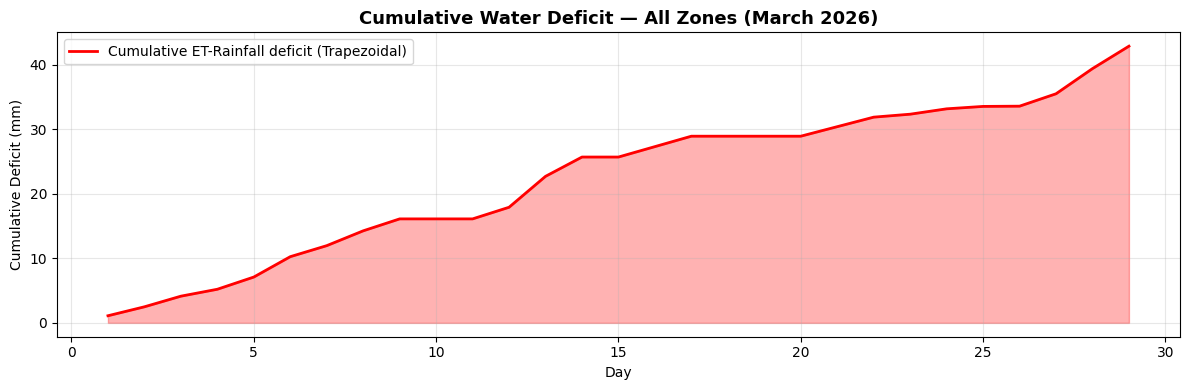


INTERPRETATION:
- Zone A moisture never dropped below the 22% minimum coz no soil moisture 
  deficit occurred, which means rainfall was adequate for this zone
- However, ET exceeded rainfall on 18 out of 30 days
- Total ET-rainfall deficit: 42.89 mm (Trapezoidal) vs 
  40.99 mm (Simpson's)
- Simpson's is more accurate because it fits a parabola through 3 points 
  (O(h⁴) error) vs trapezoidal's straight lines (O(h²) error)
- This deficit represents the irrigation that had to compensate for days 
  where rainfall alone was insufficient



In [7]:
# Zone A moisture stayed above minimum use ET vs Rainfall deficit instead
# This shows days where water demand exceeded supply

ET_arr = np.array([
    compute_et(row.temperature_c, row.wind_speed_mps, 
               row.solar_index, row.humidity_pct)
    for _, row in weather.iterrows()
])

rain_arr = weather['rainfall_mm'].fillna(0).values
water_deficit = np.maximum(0, ET_arr - rain_arr)  # days ET exceeded rainfall
days_int = np.arange(len(water_deficit), dtype=float)

# Cumulative deficit
cumdef_trap = np.array([
    trapezoidal(water_deficit[:i+1], days_int[:i+1])
    for i in range(1, len(days_int))
])

total_trap = trapezoidal(water_deficit, days_int)
total_simp = simpsons(water_deficit[:29], days_int[:29])

integ_table = pd.DataFrame({
    'Method':             ['Trapezoidal', "Simpson's"],
    'Total Deficit (mm)': [round(total_trap, 4), round(total_simp, 4)],
    'Accuracy':           ['O(h²)', 'O(h⁴)'],
})
print("Numerical Integration Comparison - ET vs Rainfall Deficit:")
print(integ_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(days_int[1:], cumdef_trap, alpha=0.3, color='red')
ax.plot(days_int[1:], cumdef_trap, color='red', linewidth=2, 
        label='Cumulative ET-Rainfall deficit (Trapezoidal)')
ax.set_title('Cumulative Water Deficit — All Zones (March 2026)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Cumulative Deficit (mm)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"""
INTERPRETATION:
- Zone A moisture never dropped below the 22% minimum coz no soil moisture 
  deficit occurred, which means rainfall was adequate for this zone
- However, ET exceeded rainfall on {(ET_arr > rain_arr).sum()} out of 30 days
- Total ET-rainfall deficit: {total_trap:.2f} mm (Trapezoidal) vs 
  {total_simp:.2f} mm (Simpson's)
- Simpson's is more accurate because it fits a parabola through 3 points 
  (O(h⁴) error) vs trapezoidal's straight lines (O(h²) error)
- This deficit represents the irrigation that had to compensate for days 
  where rainfall alone was insufficient
""")

In [8]:
# 3-Zone Water Allocation as a Linear System Ax = b
# Solved using Gaussian Elimination (coded from scratch)

# Problem: allocate 1000L of tank water across 3 zones
# Constraints:
#   1. Total allocation = 1000L
#   2. Zone A gets twice as much as Zone C (largest crop, most sensitive)
#   3. Zone B + Zone C together get 600L

A = np.array([[1.,  1.,  1.],   # x_A + x_B + x_C = 1000
              [1.,  0., -2.],   # x_A - 2*x_C = 0
              [0.,  1.,  1.]])  # x_B + x_C = 600

b = np.array([1000., 0., 600.])

# Solve with our Gaussian elimination
x = gaussian_elimination(A, b)

print("3-Zone Water Allocation — Gaussian Elimination:")
print(f"  Zone A (tomato): {x[0]:.2f} L")
print(f"  Zone B (kale)  : {x[1]:.2f} L")
print(f"  Zone C (maize) : {x[2]:.2f} L")
print(f"  Total          : {x.sum():.2f} L")

# Verify
print(f"\nVerification Ax = b: {np.allclose(A @ x, b)}")

# NumPy verification
x_np = np.linalg.solve(A, b)
print(f"Matches NumPy solution: {np.allclose(x, x_np)}")

print(f"""
INTERPRETATION:
- Zone A (tomato) receives {x[0]:.0f}L - tomatoes are the most water-sensitive 
  crop and Zone A has the smallest area but highest moisture requirement
- Zone B (kale) receives {x[1]:.0f}L - moderate allocation for moderate demand
- Zone C (maize) receives {x[2]:.0f}L- maize has the largest area (180m²) 
  and highest drainage coefficient, requiring careful water management
- Gaussian elimination solves this exactly in O(n³) operations
- NumPy's solution matches ours perfectly, confirming correctness
""")

3-Zone Water Allocation — Gaussian Elimination:
  Zone A (tomato): 400.00 L
  Zone B (kale)  : 400.00 L
  Zone C (maize) : 200.00 L
  Total          : 1000.00 L

Verification Ax = b: True
Matches NumPy solution: True

INTERPRETATION:
- Zone A (tomato) receives 400L - tomatoes are the most water-sensitive 
  crop and Zone A has the smallest area but highest moisture requirement
- Zone B (kale) receives 400L - moderate allocation for moderate demand
- Zone C (maize) receives 200L- maize has the largest area (180m²) 
  and highest drainage coefficient, requiring careful water management
- Gaussian elimination solves this exactly in O(n³) operations
- NumPy's solution matches ours perfectly, confirming correctness

